In [449]:
import torch
from torch import nn
from torch import pca_lowrank
from torch import functional as F

from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.datasets import TUDataset, MoleculeNet

from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw

from tqdm import tqdm

from sklearn.metrics import roc_auc_score

from typing import Optional

# Exploring the library and loading data

In [387]:
edge_index = torch.tensor([
    [0, 1],
    [1, 2],
    [1, 0],
    [2, 1]
], dtype=torch.long)

x = torch.tensor([[-1], [0], [1]], dtype=torch.float)

data = Data(x=x, edge_index=edge_index.T.contiguous())

In [388]:
# dataset = TUDataset(root='../datasets/FRANKENSTEIN', name='FRANKENSTEIN').shuffle()
dataset = MoleculeNet(root='../datasets/BACE', name='BACE').shuffle()

In [389]:
print(dataset)
print(dataset.num_classes)
# print(dataset.num_edge_attributes)
print(dataset.num_node_features)
print(len(dataset))

BACE(1513)
2
9
1513


In [390]:
dataset.y.unique(return_counts=True)

(tensor([0., 1.]), tensor([822, 691]))

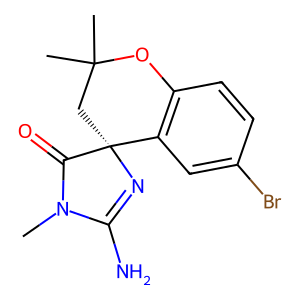

In [391]:
smiles_strn = dataset[10].smiles
mol = Chem.MolFromSmiles(smiles_strn)
Draw.MolToImage(mol)

In [392]:
len(dataset)

1513

In [393]:
dataset.x.shape

torch.Size([51577, 9])

# Training a simple GCN

In [394]:
train_set = dataset[:int(len(dataset)*0.8)]
test_set = dataset[int(len(dataset)*0.8):]
print(train_set)
print(test_set)

BACE(1210)
BACE(303)


In [395]:
train_loader = DataLoader(train_set, batch_size=64)
test_loader = DataLoader(test_set, batch_size=64)

In [396]:
all_loader = DataLoader(dataset, batch_size=64)

In [397]:
class GCN(nn.Module):
    def __init__(self, device='cpu'):
        super().__init__()
        self.device = device

        self.conv1 = GCNConv(dataset.num_node_features, 128)
        self.act = nn.ReLU()

        self.dropout = nn.Dropout(0.5)

        self.conv2 = GCNConv(128, 128)
        self.agg = global_mean_pool

        self.head1 = nn.Linear(128, 64)
        self.head2 = nn.Linear(64, 1)

        self.act2 = nn.Sigmoid()
        
        self.to(device)

    def forward(self, data):
        x = data.x.to(self.device)
        edge_index = data.edge_index.to(self.device)
        batch = data.batch.to(self.device)

        x = x.float()
        x = self.conv1(x, edge_index)
        x = self.act(x)

        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.act(x)

        x = self.dropout(x)
        
        x = self.agg(x, batch)
        
        x = self.head1(x)
        x = self.act(x)
        x = self.head2(x)
        return x# self.act2(x)





In [398]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = 'cpu'
model = GCN(device=device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
loss_fn = nn.BCEWithLogitsLoss()

In [399]:
for train_batch in train_loader:
    break
model(train_batch)

tensor([[ 0.0221],
        [ 0.0393],
        [ 0.0050],
        [ 0.0392],
        [ 0.0367],
        [ 0.0413],
        [ 0.0642],
        [ 0.0168],
        [ 0.0642],
        [ 0.0048],
        [ 0.0480],
        [ 0.0307],
        [ 0.0480],
        [ 0.0390],
        [ 0.0496],
        [ 0.0033],
        [ 0.0258],
        [ 0.0574],
        [ 0.0185],
        [ 0.0355],
        [ 0.0172],
        [ 0.0194],
        [ 0.0153],
        [-0.0179],
        [ 0.0248],
        [ 0.0279],
        [ 0.0040],
        [ 0.0454],
        [ 0.0104],
        [ 0.0116],
        [ 0.0299],
        [ 0.0347],
        [ 0.0302],
        [-0.0062],
        [ 0.0512],
        [ 0.0311],
        [ 0.0489],
        [-0.0215],
        [ 0.0156],
        [ 0.0270],
        [ 0.0321],
        [ 0.0348],
        [ 0.0208],
        [ 0.0199],
        [ 0.0309],
        [ 0.0285],
        [ 0.0441],
        [ 0.0278],
        [ 0.0357],
        [ 0.0754],
        [ 0.0541],
        [ 0.0046],
        [ 0.

In [400]:
model.train()
for epoch in (pbar := tqdm(range(1000))):
    total_loss = 0
    for train_batch in train_loader:
        optimizer.zero_grad()

        out = model(train_batch)
        loss = loss_fn(out, train_batch.y.to(device))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    pbar.set_description(f'Loss: {total_loss/len(train_loader):.4f}')
    
    # if (epoch + 1) % 50 == 0:
    #     print(f'Epoch {epoch}:', total_loss/len(all_loader))
    
        

Loss: 0.3846: 100%|██████████| 1000/1000 [02:03<00:00,  8.12it/s]


In [401]:
model.eval()
total_loss = 0
correct = 0
total_samples = 0

# Disable gradient calculation for efficiency and to prevent leakage
with torch.no_grad():
    for data in test_loader:
        
        # Forward pass: 
        # Note: For Graph Neural Networks, we typically pass atom features (x), 
        # connectivity (edge_index), and the graph identifier (batch).
        out = model(data)
        
        # Calculate loss
        loss = loss_fn(out, data.y.to(device))
        total_loss += loss.item() * data.num_graphs
        
        # Calculate accuracy
        pred = (out > 0).to(int).to(device)
        correct += int((pred == data.y.to(device)).sum())
        total_samples += data.num_graphs

avg_loss = total_loss / total_samples
accuracy = correct / total_samples

print(avg_loss, accuracy)

0.488853923361687 0.7788778877887789


In [405]:
y_pred = model(Batch.from_data_list(test_set).cpu().detach())
y_true = test_set.y
roc_auc_score(y_true, y_pred.cpu().detach())

0.8423854688618468

In [406]:
datapoint = train_set[1]
x = datapoint.x.to(device).float()
edge_index = datapoint.edge_index.to(device)

In [407]:
model.train()

GCN(
  (conv1): GCNConv(9, 128)
  (act): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (conv2): GCNConv(128, 128)
  (head1): Linear(in_features=128, out_features=64, bias=True)
  (head2): Linear(in_features=64, out_features=1, bias=True)
  (act2): Sigmoid()
)

# Single-graph batch testing PCA and attention pooling

In [408]:
# PCA through gnn

out = model.conv1(x, edge_index)
out = model.act(out)

out = model.dropout(out)

out = model.conv2(out, edge_index)
out = model.act(out)

out = model.dropout(out)

U, S, V = pca_lowrank(out)
V.retain_grad()
out = V[:, :2].flatten()

In [409]:
# Attention pooling
out = model.conv1(x, edge_index)
out = model.act(out)

out = model.dropout(out)

out = model.conv2(out, edge_index)
out = model.act(out)

out = model.dropout(out)

k = out
q = out
v = out

out = (q.matmul(k.T) / q.shape[0]).matmul(v)[0]
out

tensor([3.4181e+00, 3.1194e-02, 1.8329e-01, 4.2206e-01, 2.0184e-01, 1.0104e+00,
        6.0096e+00, 5.1186e+00, 2.3363e-01, 3.4119e-01, 4.5621e+00, 0.0000e+00,
        1.2892e+00, 5.1386e+00, 7.3709e+00, 7.5203e+00, 0.0000e+00, 1.6317e+00,
        0.0000e+00, 3.2618e+00, 0.0000e+00, 1.4945e+00, 0.0000e+00, 4.5979e-02,
        7.3144e+00, 1.9391e+00, 1.0034e-02, 6.7752e+00, 1.2990e+01, 6.8886e-03,
        4.0005e+00, 1.3202e+00, 7.9602e+00, 2.9968e+00, 6.4618e+00, 2.1890e+00,
        6.4358e+00, 5.6796e-01, 9.5365e+00, 5.3772e+00, 2.3238e-01, 2.7397e+00,
        2.6400e-02, 7.2464e+00, 5.0880e+00, 3.1074e-01, 8.2304e+00, 0.0000e+00,
        4.7435e-01, 9.5643e-01, 2.1819e-01, 1.2781e+00, 5.2962e+00, 1.3772e+00,
        0.0000e+00, 3.9169e+00, 6.6299e-01, 2.0578e+00, 3.9285e-02, 8.2881e+00,
        5.7263e+00, 3.0317e+00, 3.2449e+00, 1.7451e-01, 9.8470e-02, 4.8078e-01,
        3.5983e+00, 4.2073e+00, 1.9044e-02, 1.2932e+00, 1.3161e-01, 0.0000e+00,
        1.4268e-02, 0.0000e+00, 1.0981e+

# Testing multi-graph batch things

In [450]:
from torch_geometric.utils import scatter

In [452]:
scatter(train_batch.x, train_batch.batch, dim=0, reduce='mul').shape

torch.Size([58, 9])

In [444]:
train_batch.batch

tensor([ 0,  0,  0,  ..., 57, 57, 57])

In [437]:
train_batch.batch

tensor([ 0,  0,  0,  ..., 57, 57, 57])

In [464]:
x = train_batch.x
batch = train_batch.batch

In [466]:
q = x
k = x
v = x

In [476]:
q

tensor([[9, 0, 1,  ..., 4, 0, 0],
        [6, 0, 3,  ..., 3, 1, 1],
        [6, 0, 3,  ..., 3, 1, 1],
        ...,
        [6, 0, 4,  ..., 4, 0, 0],
        [6, 0, 4,  ..., 4, 0, 0],
        [6, 0, 4,  ..., 4, 0, 1]])

In [525]:
attn_maps = []
values = []
for i in range(train_batch.batch_size):
    attn_map = q[batch == i].matmul(k[batch == i].T)/q.shape[0]
    attn_maps.append(attn_map)
    values.append(v[batch == i])

padded_attn_maps = torch.nested.as_nested_tensor(attn_maps).to_padded_tensor(0.)
padded_values = torch.nested.as_nested_tensor(values).to_padded_tensor(0.)

padded_values.shape

# for i in range(padded_values.shape[0]):
#     print(padded_values[i])
#     print('\n==============================')
transformed_values = torch.matmul(padded_attn_maps, padded_values.to(torch.float32))

graph_representation = transformed_values[:, 0, :]

In [ ]:
def graph_attn_op_batched(q, k, v, batch, batch_size):
    '''
    Returns a padded tensor of shape (batch_size, max_node_number)
    '''
    attn_maps = []
    values = []
    for i in range(batch_size):
        attn_map = q[batch == i].matmul(k[batch == i].T)/q.shape[0]
        attn_maps.append(attn_map)
        values.append(v[batch == i])

    padded_attn_maps = torch.nested.as_nested_tensor(attn_maps).to_padded_tensor(0.)
    padded_values = torch.nested.as_nested_tensor(values).to_padded_tensor(0.)

    padded_values.shape

    # for i in range(padded_values.shape[0]):
    #     print(padded_values[i])
    #     print('\n==============================')
    return torch.matmul(padded_attn_maps, padded_values)

In [527]:
graph_attn_op_batched(x.float(), x.float(), x.float())

tensor([[[13.7273,  0.3850,  6.5999,  ...,  7.3962,  0.8226,  1.0700],
         [11.5445,  0.3325,  5.6315,  ...,  6.2479,  0.7088,  0.9232],
         [11.6753,  0.3364,  5.7103,  ...,  6.3277,  0.7141,  0.9324],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

        [[ 7.8634,  0.0000,  3.7107,  ...,  3.9859,  0.7166,  0.9324],
         [ 7.3257,  0.0000,  3.4827,  ...,  3.7268,  0.6684,  0.8702],
         [ 7.8911,  0.0000,  3.7457,  ...,  4.0112,  0.7200,  0.9373],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

        [[14.3014,  0.0000,  5.3758,  ...,  6.3505,  0.8362,  1.2713],
         [ 7.5678,  0.0000,  3.0005,  ...,  3